In [ ]:
# RONALD WILLIAM D. GERON
# CPE3B

In [19]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

In [20]:
# 1. SETUP SYMBOLS & INPUT EQUATION
s = sp.symbols('s')
Y, X = sp.symbols('Y X')

# Note: You can change the equation here. 
# Use ** or ^ for exponents (the code handles both if you use .replace below)
raw_eq_lhs = "2*s^2 * Y + s * Y"
raw_eq_rhs = "s * X + X"

# Pre-process strings to handle '^' and convert to SymPy expressions
LHS = sp.parse_expr(raw_eq_lhs.replace('^', '**'), local_dict={'s': s, 'Y': Y})
RHS = sp.parse_expr(raw_eq_rhs.replace('^', '**'), local_dict={'s': s, 'X': X})

In [21]:
# 2. DERIVE TRANSFER FUNCTION G(s) = Y/X

# Solve the equation for Y, then divide by X to get the ratio
y_solved = sp.solve(sp.Eq(LHS, RHS), Y)[0]
G_s = sp.simplify(y_solved / X)

print("--- Step 1: Symbolic Transfer Function ---")
sp.pprint(G_s)


--- Step 1: Symbolic Transfer Function ---
   s + 1   
───────────
s⋅(2⋅s + 1)


In [22]:
# 3. CONVERT TO CONTROL LIBRARY FORMAT

num, den = sp.fraction(G_s)

# Extract coefficients as integers for a clean "textbook" look
num_coeffs = [int(c) for c in sp.Poly(num, s).all_coeffs()]
den_coeffs = [int(c) for c in sp.Poly(den, s).all_coeffs()]

print(f"\nNumerator coefficients: {num_coeffs}")
print(f"Denominator coefficients: {den_coeffs}")

# Create the official Control System object
sys = ctrl.TransferFunction(num_coeffs, den_coeffs)

print("\nSystem Representation:")
print(sys) # Displays with the dashed line (e.g., s+1 / 2s^2+s)



Numerator coefficients: [1, 1]
Denominator coefficients: [2, 1, 0]

System Representation:
<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s



--- Step 2: System Analysis ---
Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


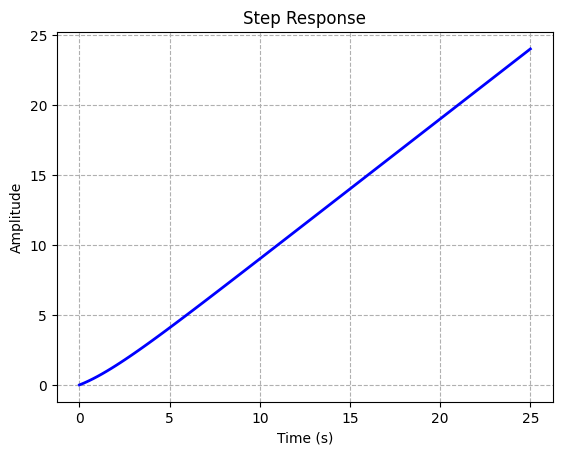

In [27]:
# 4. SYSTEM ANALYSIS

print("\n--- Step 2: System Analysis ---")
print(f"Poles: {ctrl.poles(sys)}")
print(f"Zeros: {ctrl.zeros(sys)}")

# Plot Step Response

t, y = ctrl.step_response(sys)
plt.plot(t, y, label='Output y(t)', color='blue', linewidth=2)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')

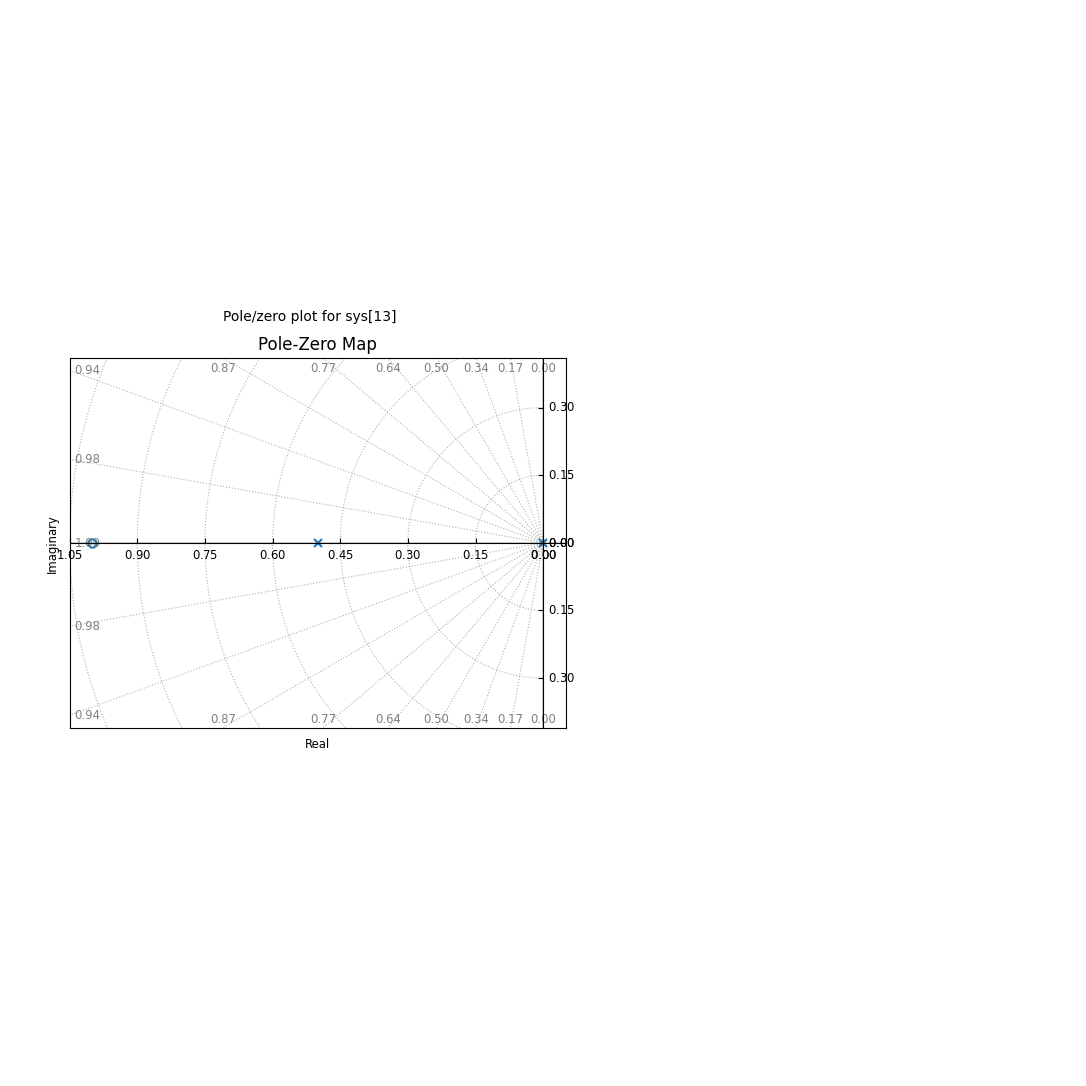

In [28]:
# Plot Pole-Zero Map
ctrl.pzmap(sys, grid=True)
plt.title('Pole-Zero Map')

plt.show()